In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
import h5py
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation

In [2]:
datasets_0 = [
            '20241202_8e-8mbar_long',
            '20241204_2e-8mbar_8e_aftercal_long',
            '20241205_2e-8mbar_0e_aftercal_long',
            '20241206_1e-8mbar_0e_aftercal_long',
            '20241207_1e-8mbar_1e_aftercal_long',
            '20241208_1e-8mbar_1e_aftercal_long',
            '20241210_1e-8mbar_8e_alignment1_long',
            '20241210_1e-8mbar_8e_alignment2_long_withdrive',
            '20241210_1e-8mbar_8e_alignment2_long_nodrive',
            '20241211_1e-8mbar_8e_alignment2_long_nodrive',
            '20241212_1e-8mbar_8e_alignment2_long_nodrive',
            '20241213_1e-8mbar_0e_alignment2_long',
            '20241214_1e-8mbar_0e_alignment2_long',
            '20241215_9e-9mbar_0e_alignment2_long',
            '20241216_5e-8mbar_0e_alignment2_long',
            '20241217_6e-8mbar_0e_alignment3_long',
            ]

datasets_1 = ['20250104_4e-8mbar_alignment0_long',
            '20250105_2e-8mbar_alignment0_long',
            '20250106_2e-8mbar_8e_alignment0_long',
            '20250107_1e-8mbar_8e_alignment0_long',
            '20250108_1e-8mbar_8e_alignment0_long',
            '20250109_1e-8mbar_8e_alignment1_long',
            '20250110_1e-8mbar_8e_alignment1_long',
            '20250111_1e-8mbar_8e_alignment1_long',
            '20250112_9e-9mbar_8e_alignment1_long',
            '20250113_5e-8mbar_8e_alignment1_long',
            '20250114_1e-8mbar_1e_alignment1_long',
            '20250115_8e-9mbar_0e_alignment1_long',
            '20250116_8e-9mbar_0e_alignment1_long_wrong_lo',
            '20250117_8e-9mbar_0e_alignment1_long',
            '20250118_8e-9mbar_1e_alignment1_long',
            '20250120_8e-9mbar_1e_alignment1_long_wbackscat',
            '20250121_8e-9mbar_1e_alignment1_long',
            '20250122_8e-9mbar_1e_alignment1_long',
            '20250123_7e-9mbar_1e_alignment1_long',
            '20250124_7e-9mbar_1e_alignment1_long',
            '20250125_7e-9mbar_1e_alignment1_long'    
        ]
datasets_2 = ['20241222_5e-8mbar_10e_alignment0_long']
datasets_3 = ['20241227_6e-8mbar_alignment0_long']

In [3]:
def get_local_hour(utc_offset, t_utc):
    t_locals = t_utc + TimeDelta(utc_offset * 3600, format='sec')

    t_local_hours = np.empty(t_locals.size)
    for i, t_local in enumerate(t_locals):
        t_local_hours[i] = t_local.datetime.hour + t_local.datetime.minute/60 + t_local.datetime.second/3600

    return t_local_hours

def group_into_days(hours):
    idx_day = np.where(np.diff(hours)<0)[0]

    hours_day = []
    for i, idx_end in enumerate(idx_day):
        if i == 0:
            idx_start = 0
        else:
            idx_start = idx_day[i-1]
        hours_day.append(hours[idx_start+1:idx_end+1])

    # Add the final day
    hours_day.append(hours[idx_end+1:])

    return hours_day

In [4]:
def read_summed_hists(datasets):
    time_per_search = 50e-6 # s
    out_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data/for_background'

    bc = None
    hists, livetimes = [], []
    for dataset in datasets:
        outfile_name = f'{dataset}_summed_histograms.hdf5'
        _file = h5py.File(os.path.join(out_dir, outfile_name), 'r')
        
        if bc is None:
            bc = _file['summed_histograms'].attrs['bc']
        hh_det_noise = _file['summed_histograms']['hh_det_noise_sum'][:]
        hh_det_noise_chi2 = _file['summed_histograms']['hh_det_noise_chi2_sum'][:]

        hists.append(hh_det_noise_chi2)
        livetimes.append(np.sum(hh_det_noise) * time_per_search)

        _file.close()
        
    return bc, livetimes, hists

In [5]:
bc_0, livetimes_0, hists_20241202 = read_summed_hists(datasets_0)
bc_1, livetimes_1, hists_20250103 = read_summed_hists(datasets_1)
bc_2, livetimes_2, hists_20241221 = read_summed_hists(datasets_2)
bc_3, livetimes_3, hists_20241226 = read_summed_hists(datasets_3)

/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_17498/219317001.py:15: RuntimeWarning: divide by zero encountered in log10
  ax0.plot(bc_0, np.log10(hists_20250103[20-i]/livetimes_1[20-i]), z[20-i], zdir='y', color=colors[20-i])
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_17498/219317001.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_17498/219317001.py:117: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()
/Users/yuhan/anaconda3/envs/nanospheres/lib/python3.12/site-packages/mpl_toolkits/mplot3d/proj3d.py:177: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0]/w, vecw[1]/w, vecw[2]/w
/Users/yuhan/anaconda3/envs/nanospheres/lib/python3.12/site-packages/mpl_toolkits/mplot3d/proj3d.py:1

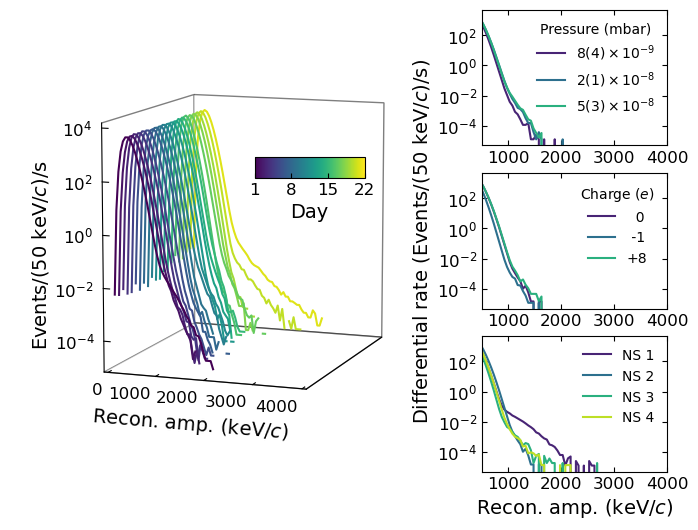

In [7]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3D
from matplotlib.ticker import MultipleLocator
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig = plt.figure(figsize=(11, 6))
ax0 = fig.add_subplot(1, 1, 1, projection='3d')

cmap = plt.colormaps.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, 22))

z = np.arange(0, 21, 1)
for i in range(len(hists_20250103)):
    ax0.plot(bc_0, np.log10(hists_20250103[20-i]/livetimes_1[20-i]), z[20-i], zdir='y', color=colors[20-i])

ax0.set_yticks([])

# Hide grid and background pane fill
ax0.grid(False)
ax0.xaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
ax0.yaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
ax0.zaxis.pane.set_facecolor((1.0, 1.0, 1.0, 0.0))

# Show the pane edges clearly
ax0.xaxis.pane.set_edgecolor('black')
ax0.yaxis.pane.set_edgecolor('black')
ax0.zaxis.pane.set_edgecolor('black')

# Adjusting the ticks and ticklabels
[t.set_va('center') for t in ax0.get_xticklabels()]
[t.set_ha('right') for t in ax0.get_xticklabels()]
[t.set_va('center') for t in ax0.get_zticklabels()]
[t.set_ha('right') for t in ax0.get_zticklabels()]

ax0.xaxis._axinfo['tick']['inward_factor'] = 0
ax0.xaxis._axinfo['tick']['outward_factor'] = 0.4
ax0.zaxis._axinfo['tick']['inward_factor'] = 0
ax0.zaxis._axinfo['tick']['outward_factor'] = 0.4

ax0.set_zticks([-4, -2, 0, 2, 4])
ax0.set_zticklabels(['$10^{-4}$', '$10^{-2}$', '$10^{0}$', '$10^{2}$', '$10^{4}$'])

ax0.xaxis.set_major_locator(MultipleLocator(1000))
ax0.zaxis.set_major_locator(MultipleLocator(2))
ax0.xaxis.set_tick_params(pad=2)
ax0.zaxis.set_tick_params(pad=-2.5)

# Tricks to move z axis to the left
tmp_planes = ax0.zaxis._PLANES 
ax0.zaxis._PLANES = ( tmp_planes[2], tmp_planes[3], 
                     tmp_planes[0], tmp_planes[1], 
                     tmp_planes[4], tmp_planes[5])

ax0.view_init(elev=10, azim=-70)
ax0.set_xlim(0, 4000)

ax0.set_xlabel('Recon. amp. (keV/$c$)')
ax0.zaxis.set_rotate_label(False)
ax0.set_zlabel('Events/(50 keV/$c$)/s', labelpad=15, rotation=90)

# Create a fake mappable for the colorbar
norm = Normalize(vmin=1, vmax=22)  # Adjust based on what your z index represents
sm = ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  # required for matplotlib to handle the ScalarMappable

cax = fig.add_axes([0.525, 0.6, 0.1, 0.035])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('Day')
cbar.set_ticks([1, 8, 15, 22])

ax0.set_box_aspect([0.85, 1, 1], zoom=0.85)

## ================================================
## ================================================

ax1 = plt.subplot(3, 4, 4)
ax2 = plt.subplot(3, 4, 8)
ax3 = plt.subplot(3, 4, 12)

colors = cmap(np.linspace(0.1, 0.9, 4))

idx_plot = [17, 2, 9]
labels_pressure = ['$8(4) \\times 10^{{-9}}$', '$2(1) \\times 10^{{-8}}$', '$5(3) \\times 10^{{-8}}$']
for i, idx in enumerate(idx_plot):
    ax1.plot(bc_0, hists_20250103[idx]/livetimes_1[idx], label=labels_pressure[i], color=colors[i])

idx_plot = [11, 15, 7]
labels_charge = [r'  0', r' -1', r'+8']
for i, idx in enumerate(idx_plot):
    ax2.plot(bc_0, hists_20250103[idx]/livetimes_1[idx], label=labels_charge[i], color=colors[i])

ax3.plot(bc_0, hists_20241202[3]/livetimes_0[3], label='NS 1', color=colors[0])
ax3.plot(bc_0, hists_20250103[11]/livetimes_1[11], label='NS 2', color=colors[1])
ax3.plot(bc_0, hists_20241221[0]/livetimes_2[0], label='NS 3', color=colors[2])
ax3.plot(bc_0, hists_20241226[0]/livetimes_3[0], label='NS 4', color=colors[3])

for a in [ax1, ax2, ax3]:
# for a in [ax0]:
    a.set_yscale('log')
    a.set_xlim(500, 4000)
    a.set_ylim(5e-6, 5e3)

for a in [ax1, ax2, ax3]:
    if a == ax1:
        a.legend(frameon=False, fontsize=10, title='Pressure (mbar)')
    elif a == ax2:
        a.legend(frameon=False, fontsize=10, title=r'Charge ($e$)')
    else:
        a.legend(frameon=False, fontsize=10)
    a.xaxis.set_major_locator(MultipleLocator(1000))
    a.yaxis.set_ticks([1e-4, 1e-2, 1e0, 1e2])

ax3.set_xlabel('Recon. amp. (keV/$c$)', fontsize=14)
ax2.set_ylabel('Differential rate (Events/(50 keV/$c$)/s)', fontsize=14)

fig.tight_layout()
fig.align_labels()

plt.savefig('../paper_plots/background_characterization.pdf', bbox_inches='tight', dpi=600)

## Daily modulation

In [7]:
def bin_events_day(hour_day, bins):
    ret = []
    for hours in hour_day:
        _hist, _ = np.histogram(hours, bins=bins)
        ret.append(_hist)

    return np.array(ret)

def get_hist_livetime(sphere, datasets, sidereal=True):
    time_prefix = 'sidereal' if sidereal else 'solar'

    ret = []
    _hist_tmp = None
    
    for dataset in datasets:
        # print(dataset)

        npz = np.load(fr'E:\livetime_window\{sphere}\{sphere}_{dataset}_hist_livetime_window_{time_prefix}.npz', allow_pickle=True)
        hist_0 = npz['hist_0']
        hist_1 = npz['hist_1']
        try:
            hist_2 = npz['hist_2']
            if hist_2.size == 1:
                hist_2 = None

        except:
            hist_2 = None
        npz.close()

        if hist_1.size == 1:
            hist_1 = None

        # print(hist_0)
        # print(hist_1)
            
        if _hist_tmp is not None:
            if np.min(np.nonzero(hist_0)) < np.max(np.nonzero(_hist_tmp)):
                ret.append(_hist_tmp)
            else:
                hist_0 += _hist_tmp
        
        if hist_2 is None:
            if hist_1 is not None:
                ret.append(hist_0)
                _hist_tmp = hist_1
            else:
                _hist_tmp = hist_0
        else:
            ret.append(hist_0)
            ret.append(hist_1)
            _hist_tmp = hist_2

    ret.append(_hist_tmp)

    return np.array(ret)

In [26]:
# solar_0 = get_hist_livetime('sphere_20241202', datasets_0, sidereal=False)
# sidereal_0 = get_hist_livetime('sphere_20241202', datasets_0, sidereal=True)

# solar_1 = get_hist_livetime('sphere_20250103', datasets_1, sidereal=False)
# sidereal_1 = get_hist_livetime('sphere_20250103', datasets_1, sidereal=True)

# np.savez('livetime_windows_day.npz', solar_0=solar_0, sidereal_0=sidereal_0, solar_1=solar_1, sidereal_1=sidereal_1)

In [27]:
latitude_newhaven  = 41.31 # deg
longitude_newhaven = -72.923611 # deg
elevation_newhaven = 18 # m

amp2kev_sphere_20241202 = 5945.245097647231
amp2kev_sphere_20250103 = 5923.2059527417405

In [28]:
# data_dir = r'C:\Users\yuhan\dm_nanospheres\data_processed\sphere_data'
data_dir = r'/Users/yuhan/work/nanospheres/dm_nanospheres/data_processed/sphere_data'

file0 = h5py.File(rf'{data_dir}/sphere_20241202_unbinned_amps.h5py')
file1 = h5py.File(rf'{data_dir}/sphere_20250103_unbinned_amps.h5py')

amps0 = file0['unbinned_amps']['amplitude'][:]
amps1 = file1['unbinned_amps']['amplitude'][:]
time0 = file0['unbinned_amps']['time'][:]
time1 = file1['unbinned_amps']['time'][:]

file0.close()
file1.close()

In [29]:
thr_kev = 1250
location = EarthLocation(lat=latitude_newhaven, lon=longitude_newhaven, height=elevation_newhaven)

t0 = Time(time0, format='unix', scale='utc')
t1 = Time(time1, format='unix', scale='utc')

# Calculate the sidereal time
lst0 = t0[np.abs(amps0)*amp2kev_sphere_20241202 > thr_kev].sidereal_time('apparent', longitude=location.lon)
lst1 = t1[np.abs(amps1)*amp2kev_sphere_20250103 > thr_kev].sidereal_time('apparent', longitude=location.lon)

# Group sidereal times into days
_lst0_hour = lst0.hour
_lst1_hour = lst1.hour

hour_day_sidereal_0 = group_into_days(_lst0_hour)
hour_day_sidereal_1 = group_into_days(_lst1_hour)

# Calculate the local time (UTC-5) during data taking
utc_offset = -5

_t0_local_hours = get_local_hour(utc_offset, t0[np.abs(amps0)*amp2kev_sphere_20241202 > thr_kev])
_t1_local_hours = get_local_hour(utc_offset, t1[np.abs(amps1)*amp2kev_sphere_20250103 > thr_kev])

hour_day_solar_0 = group_into_days(_t0_local_hours)
hour_day_solar_1 = group_into_days(_t1_local_hours)

In [30]:
# Bin events in individual days into histograms
bins = np.linspace(0, 24, 25)
bc = 0.5 * (bins[1:] + bins[:-1])

hist_day_sidereal_0 = bin_events_day(hour_day_sidereal_0, bins)
hist_day_sidereal_1 = bin_events_day(hour_day_sidereal_1, bins)
hist_day_solar_0 = bin_events_day(hour_day_solar_0, bins)
hist_day_solar_1 = bin_events_day(hour_day_solar_1, bins)

In [31]:
# Read in the effective livetime (# of windows) for each day
# after livetime selection
npz_livetime = np.load('livetime_windows_day.npz')

livetime_sidereal_0 = npz_livetime['sidereal_0']
livetime_sidereal_1 = npz_livetime['sidereal_1']
livetime_solar_0 = npz_livetime['solar_0']
livetime_solar_1 = npz_livetime['solar_1']

npz_livetime.close()

In [32]:
rate_sidereal_0 = hist_day_sidereal_0 / (livetime_sidereal_0 * 10e-3 / 3600)
rate_sidereal_1 = hist_day_sidereal_1 / (livetime_sidereal_1 * 10e-3 / 3600)
rate_solar_0    = hist_day_solar_0 / (livetime_solar_0 * 10e-3 / 3600)
rate_solar_1    = hist_day_solar_1 / (livetime_solar_1 * 10e-3 / 3600)

/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_5924/705212906.py:1: RuntimeWarning: invalid value encountered in divide
  rate_sidereal_0 = hist_day_sidereal_0 / (livetime_sidereal_0 * 10e-3 / 3600)
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_5924/705212906.py:2: RuntimeWarning: invalid value encountered in divide
  rate_sidereal_1 = hist_day_sidereal_1 / (livetime_sidereal_1 * 10e-3 / 3600)
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_5924/705212906.py:3: RuntimeWarning: invalid value encountered in divide
  rate_solar_0    = hist_day_solar_0 / (livetime_solar_0 * 10e-3 / 3600)
/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_5924/705212906.py:4: RuntimeWarning: invalid value encountered in divide
  rate_solar_1    = hist_day_solar_1 / (livetime_solar_1 * 10e-3 / 3600)


In [33]:
print(np.sum( rate_sidereal_0 > 1e5 ))
print(np.sum( rate_sidereal_1 > 1e5) )
print(np.sum( rate_solar_0 > 1e5) )
print(np.sum( rate_solar_1 > 1e5) )

0
0
0
0


In [21]:
def get_mean_rate(hist_day, livetime_day, hour_per_bin=1):
    hist_sum = np.empty(hist_day.shape[1])
    livetime_sum  = np.empty(hist_day.shape[1])

    livetime_day_hour = livetime_day * 10e-3 / 3600

    hist_bin = hist_day.T
    livetime_hour_bin = livetime_day_hour.T
    for i, bin in enumerate(hist_bin):
        good_bin_idx = livetime_hour_bin[i] > 0

        hist_sum[i] = np.sum(bin[good_bin_idx])
        livetime_sum[i] = np.sum(livetime_hour_bin[i][good_bin_idx])

        # mean_rate[i] = np.sum(bin[good_bin_idx]) / np.sum(livetime_hour_bin[i][good_bin_idx])
        # err_rate[i]  = np.sqrt(np.sum(bin[good_bin_idx])) / np.sum(livetime_hour_bin[i][good_bin_idx])

    n_rate = int(hist_day.shape[1] / hour_per_bin)
    mean_rate, err_rate = np.empty(n_rate), np.empty(n_rate)

    for i in range(n_rate):
        n_events = np.sum(hist_sum[i*hour_per_bin:(i*hour_per_bin + hour_per_bin)])
        livetime = np.sum(livetime_sum[i*hour_per_bin:(i*hour_per_bin + hour_per_bin)])
        mean_rate[i] = n_events / livetime
        err_rate[i] = np.sqrt(n_events) / livetime

    return mean_rate, err_rate

In [ ]:
# Calculate mean event rate over days
mean_sidereal_0, err_sidereal_0 = get_mean_rate(hist_day_sidereal_0, livetime_sidereal_0, hour_per_bin=1)
mean_sidereal_1, err_sidereal_1 = get_mean_rate(hist_day_sidereal_1, livetime_sidereal_1, hour_per_bin=1)

# mean_solar_0, err_solar_0 = get_mean_rate(hist_day_solar_0, livetime_solar_0)
# mean_solar_1, err_solar_1 = get_mean_rate(hist_day_solar_1, livetime_solar_1)

#### Perform binned likelihood fit for each day

Event rates have already corrected for livetime. Fit a signal model
\begin{equation}
    R(t) = A \cos(\frac{2 \pi}{T} (t - t_0)) + B,
\end{equation}
where $T$ is fixed at 24 (or 12) hours.

In [34]:
from scipy.optimize import minimize

def get_mui(bc, A, B, t0):
    return A * np.abs(np.cos(2 * np.pi * (bc - t0) / 24)) + B
    # return A * np.cos(2 * np.pi * (bc - t0) / 12) + B

def nll_sidereal_hour(A, B, t0, bc, rate_hour):
    mui = get_mui(bc, A, B, t0)
    ni = rate_hour

    return np.sum(np.nan_to_num(mui - ni * np.log(mui)))

def nll_sidereal_rate_hour_all(A, B, t0, bc, rate_hour_all):
    mui = get_mui(bc, A, B, t0)

    _nll = 0
    for rate_hour in rate_hour_all:
        ni = rate_hour
        _nll += np.sum(np.nan_to_num(mui - ni * np.log(mui)))
    return _nll

def minimize_nll_sidereal(bc, rate_hour_all, bounds=None):
    args = (bc, rate_hour_all)

    res = minimize(fun=lambda x: nll_sidereal_rate_hour_all(*x, *args), x0=[10, np.mean(rate_hour_all[~np.isnan(rate_hour_all)]), 5],
            method='Nelder-Mead',
            bounds=[(-300, 300), (0, 400), (0, 24)],
            options={'disp' : False,
                    'maxiter': 50000,
                    'maxfev': 50000,
                    'adaptive': True,
                    'fatol': 0.001,
                    }
            )
    if res.success:
        return res.fun, res.x
    else:
        return None, None

def profile_nll_sidereal_rate_hour_all(B, t0, bc, rate_hour_all, A):
    mui = get_mui(bc, A, B, t0)

    _nll = 0
    for rate_hour in rate_hour_all:
        ni = rate_hour
        _nll += np.sum(np.nan_to_num(mui - ni * np.log(mui)))
    return _nll

def profile_nll_sidereal(bc, rate_hour_all, A, bounds=None):
    args = (bc, rate_hour_all, A)

    res = minimize(fun=lambda x: profile_nll_sidereal_rate_hour_all(*x, *args), x0=[np.mean(rate_hour_all[~np.isnan(rate_hour_all)]), 5],
            method='Nelder-Mead',
            bounds=[(0, 400), (0, 24)],
            options={'disp' : False,
                    'maxiter': 50000,
                    'maxfev': 50000,
                    'adaptive': True,
                    'fatol': 0.001,
                    }
            )
    if res.success:
        return res.fun, res.x
    else:
        return None, None

In [35]:
aa_0 = np.linspace(0, 10, 50)
aa_1 = np.linspace(0, 10, 50)

profile_nll_0, profile_nll_1 = np.empty_like(aa_0), np.empty_like(aa_1)
for i, a in enumerate(aa_0):
    profile_nll_0[i] = profile_nll_sidereal(bc, rate_sidereal_0, a)[0]
for i, a in enumerate(aa_1):
    profile_nll_1[i] = profile_nll_sidereal(bc, rate_sidereal_1, a)[0]

nll_0, nll_params_0 = minimize_nll_sidereal(bc, rate_sidereal_0)
nll_1, nll_params_1 = minimize_nll_sidereal(bc, rate_sidereal_1)

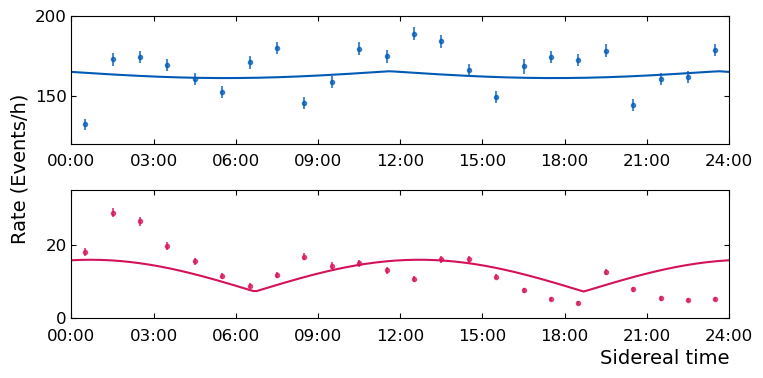

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4))

bins = np.linspace(0, 24, 25)
bc = 0.5 * (bins[1:] + bins[:-1])

axes[0].errorbar(bc, (mean_sidereal_0), yerr=err_sidereal_0, fmt='.', color='#005AB5', alpha=0.7, label='Nanosphere 1')
axes[1].errorbar(bc, (mean_sidereal_1), yerr=err_sidereal_1, fmt='.', color='#D41159', alpha=0.7)

xx = np.linspace(0, 24, 200)
axes[0].plot(xx, get_mui(xx, *nll_params_0), color='#005AB5', linestyle='-')
axes[1].plot(xx, get_mui(xx, *nll_params_1), color='#D41159', linestyle='-')

# axes[0].legend(frameon=False, fontsize=12, framealpha=0.5, edgecolor='k')
fig.supylabel('Rate (Events/h)', fontsize=14, x=0.045, y=0.55)
axes[1].set_xlabel('Sidereal time', ha='right', x=1.0, fontsize=14)

def float_to_time(x, pos):
    hour = int(x)
    minute = int((x - hour) * 60)
    return f"{hour:02d}:{minute:02d}"

for ax in axes:
    # ax.hlines(y=0, xmin=0, xmax=24, color='k', linestyle='--', linewidth=1)
    ax.set_xlim(0, 24)

    ax.set_xticks(np.arange(0, 27, 3))  # every 3 hours
    ax.tick_params(axis='x', which='major', pad=7.5)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(float_to_time))

axes[0].set_ylim(120, 200)
axes[1].set_ylim(0, 35)

fig.tight_layout(pad=1.5)
# plt.savefig('../paper_plots/daily_modulation.pdf', dpi=600)

In [37]:
# fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# axes[0].errorbar(bc, mean_solar_0, yerr=err_solar_0, fmt='.', color='#005AB5', alpha=0.7, label='Nanosphere 1')
# axes[0].errorbar(bc+0.1, mean_solar_1, yerr=[[min(mean_solar_1[i], err_solar_1[i]) for i in range(err_solar_1.size)], err_solar_1], fmt='.', color='#D41159', alpha=0.7, label='Nanosphere 2')

# axes[1].errorbar(bc, mean_sidereal_0, yerr=err_sidereal_0, fmt='.', color='#005AB5', alpha=0.7)
# axes[1].errorbar(bc+0.1, mean_sidereal_1, yerr=[[min(mean_sidereal_1[i], err_sidereal_1[i]) for i in range(err_sidereal_1.size)], err_sidereal_1], fmt='.', color='#D41159', alpha=0.7)

# xx = np.linspace(0, 24, 200)
# axes[1].plot(xx, get_mui(xx, *nll_params_0), color='#005AB5', linestyle='-')
# axes[1].plot(xx, get_mui(xx, *nll_params_1), color='#D41159', linestyle='-')

# axes[0].legend(frameon=True, fontsize=12, framealpha=0.5, edgecolor='k')
# fig.supylabel('Rate (Events/h)', fontsize=14, x=0.045)
# axes[0].set_xlabel('Solar time', ha='right', x=1.0, fontsize=14)
# axes[1].set_xlabel('Sidereal time', ha='right', x=1.0, fontsize=14)

# def float_to_time(x, pos):
#     hour = int(x)
#     minute = int((x - hour) * 60)
#     return f"{hour:02d}:{minute:02d}"

# for ax in axes:
#     # ax.hlines(y=0, xmin=0, xmax=24, color='k', linestyle='--', linewidth=1)
#     ax.set_xlim(0, 24)
#     # ax.set_ylim(0, 40)

#     ax.set_xticks(np.arange(0, 27, 3))  # every 3 hours
#     ax.tick_params(axis='x', which='major', pad=7.5)

#     ax.xaxis.set_major_formatter(plt.FuncFormatter(float_to_time))

# fig.tight_layout(pad=1.5)
# # plt.savefig('../paper_plots/daily_modulation.pdf', dpi=600)

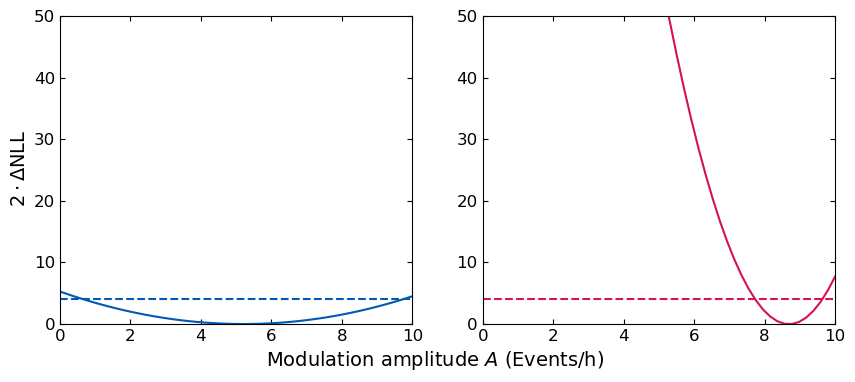

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(aa_0, 2*(profile_nll_0 - np.min(profile_nll_0)), color='#005AB5')
axes[1].plot(aa_1, 2*(profile_nll_1 - np.min(profile_nll_1)), color='#D41159')
# plt.plot(aa_0, profile_nll_0 + profile_nll_1 - np.min(profile_nll_0+profile_nll_1), 'k')

axes[0].hlines(y=4, xmin=0, xmax=10, linestyle='--', color='#005AB5')
axes[1].hlines(y=4, xmin=0, xmax=10, linestyle='--', color='#D41159')

fig.supxlabel(r'Modulation amplitude $A$ (Events/h)', fontsize=14, y=-0.01)
fig.supylabel(r'$2 \cdot \Delta$NLL', fontsize=14, x=0.075)

for ax in axes:
    ax.set_ylim(0, 50)
    ax.set_xlim(0, 10)

#### Now select only data in the middle from the second sphere

In [39]:
# Select only time in the middle for this analysis
hist_day_sidereal_1_mod = np.copy(hist_day_sidereal_1)
livetime_sidereal_1_mod = np.copy(livetime_sidereal_1)
hist_day_sidereal_1_mod[0][0:16] = 0
livetime_sidereal_1_mod[0][0:16] = 0
hist_day_sidereal_1_mod[-2][9:] = 0
livetime_sidereal_1_mod[-2][9:] = 0
hist_day_sidereal_1_mod[-1][:] = 0
livetime_sidereal_1_mod[-1][:] = 0

mean_sidereal_1_mod, err_sidereal_1_mod = get_mean_rate(hist_day_sidereal_1_mod, livetime_sidereal_1_mod, hour_per_bin=1)
rate_sidereal_1_mod = hist_day_sidereal_1_mod / (livetime_sidereal_1_mod * 10e-3 / 3600)

print(f'Total livetime: {np.sum(livetime_sidereal_1_mod * 10e-3 / 3600) / 24:.2f} days,  {np.sum(livetime_sidereal_1_mod * 10e-3 / 3600) / 24 /(365.24/366.24):.2f} sidereal days')


Total livetime: 15.91 days,  15.96 sidereal days


/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_5924/1798012397.py:12: RuntimeWarning: invalid value encountered in divide
  rate_sidereal_1_mod = hist_day_sidereal_1_mod / (livetime_sidereal_1_mod * 10e-3 / 3600)


In [41]:
aa = np.linspace(0, 3, 50)
profile_nll_1_mod = np.empty_like(aa)
for i, a in enumerate(aa):
    profile_nll_1_mod[i] = profile_nll_sidereal(bc, rate_sidereal_1_mod, a)[0]

def minimize_nll_sidereal(bc, rate_hour_all, bounds=None):
    args = (bc, rate_hour_all)

    res = minimize(fun=lambda x: nll_sidereal_rate_hour_all(*x, *args), x0=[1, np.mean(rate_hour_all[~np.isnan(rate_hour_all)]), 5],
            method='Nelder-Mead',
            bounds=[(-300, 300), (0, 400), (0, 24)],
            options={'disp' : False,
                    'maxiter': 50000,
                    'maxfev': 50000,
                    'adaptive': True,
                    'fatol': 0.001,
                    }
            )

    if res.success:
        return res.fun, res.x
    else:
        return None, None

nll_1_mod, nll_params_1_mod = minimize_nll_sidereal(bc, rate_sidereal_1_mod)

[2.02723485 2.51779685 8.95926698]


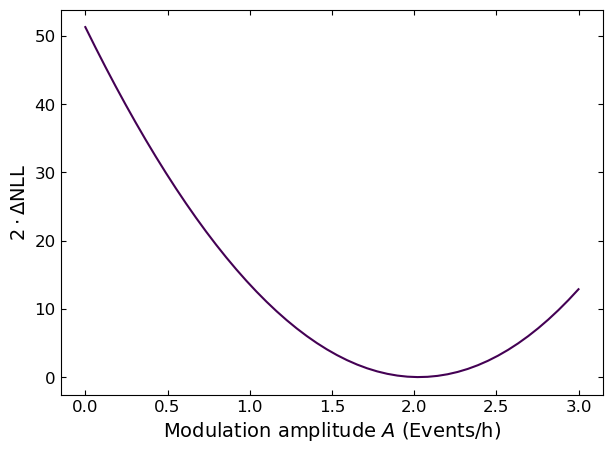

In [42]:
plt.plot(aa, 2*(profile_nll_1_mod - np.min(profile_nll_1_mod)))
plt.xlabel(r'Modulation amplitude $A$ (Events/h)', fontsize=14, y=-0.01)
plt.ylabel(r'$2 \cdot \Delta$NLL', fontsize=14, x=0.075)

print(nll_params_1_mod)

In [47]:
# Calculate the model parameters at 95% CL upper limit
nllx2 = 2*(profile_nll_1_mod - np.min(profile_nll_1_mod))
idx_search = aa > 2

upper_A = np.interp(4, nllx2[idx_search], aa[idx_search])
profile_nll_upper, profile_nll_params_upper = profile_nll_sidereal(bc, rate_sidereal_1_mod, upper_A)

In [48]:
npz = np.load(r'/Users/yuhan/work/nanospheres/dm_nanospheres/analysis_notebooks/rate_sidereal_hour.npz')
lst = npz['lst']
rate_lst = npz['rate_events_h']

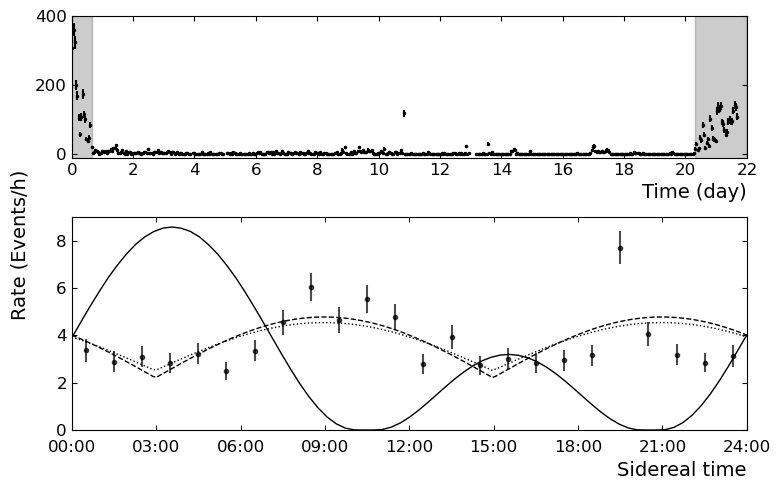

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), height_ratios=[1, 1.5])

xx = (np.arange(rate_sidereal_1.flatten().size) + 0.5) / 24
axes[0].errorbar(xx, rate_sidereal_1.flatten(), yerr=np.sqrt(rate_sidereal_1.flatten()), 
                 fmt='.', color='k', markersize=3)
axes[1].errorbar(bc, (mean_sidereal_1_mod), yerr=err_sidereal_1_mod, fmt='.', color='k', alpha=0.7)

axes[0].fill_betweenx(np.arange(-100, 500, 50), 0, 16/24, color='k', alpha=0.2)
axes[0].fill_betweenx(np.arange(-100, 500, 50), np.max(xx)-40/24, np.max(xx), color='k', alpha=0.2)

xx = np.linspace(0, 24, 200)
axes[1].plot(xx, get_mui(xx, *nll_params_1_mod), color='k', linestyle=':', linewidth=1)
axes[1].plot(xx, get_mui(xx, upper_A, *profile_nll_params_upper), color='k', linestyle='--', linewidth=1)

# Plot the expected DM modulation signal
axes[1].plot(lst, rate_lst, color='k', linestyle='-', linewidth=1)

axes[0].set_ylim(-10, 400)
axes[0].set_xlim(0, 22)
axes[0].set_xticks(np.arange(0, 24, 2))

axes[1].set_xlim(0, 24)
axes[1].set_ylim(0, 9)

fig.supylabel('Rate (Events/h)', fontsize=14, x=0.03, y=0.5)
axes[0].set_xlabel('Time (day)', ha='right', x=1.0, fontsize=14)
axes[1].set_xlabel('Sidereal time', ha='right', x=1.0, fontsize=14)

def float_to_time(x, pos):
    hour = int(x)
    minute = int((x - hour) * 60)
    return f"{hour:02d}:{minute:02d}"

axes[1].set_xticks(np.arange(0, 27, 3))  # every 3 hours
axes[1].tick_params(axis='x', which='major', pad=7.5)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(float_to_time))

fig.tight_layout()
plt.savefig('../paper_plots/daily_modulation.pdf', dpi=600)

In [17]:
####
#  Previous (unsuccessfully) methods of getting
#  the effective livetime
####

# def get_livetime(bins, t_begin, t_end):
#     bin_size = bins[1] - bins[0]
#     ret = np.ones(bins.size - 1) * bin_size

#     for i, b in enumerate(ret):
#         if bins[i+1] < t_begin or bins[i] > t_end:
#             ret[i] = 0
#         if bins[i] < t_begin and bins[i+1] > t_begin:
#             ret[i] = (bins[i+1] - t_begin) / bin_size
#         if bins[i] < t_end and bins[i+1] > t_end:
#             ret[i] = (bins[i+1] - t_end) / bin_size

#     return ret

# def get_estimated_livetimes(bins, hour_day, time, sidereal=True):
#     ret = np.zeros(shape=(len(hour_day), bins.size-1))

#     _tt = Time(np.array([time[0], time[-1]]), format='unix', scale='utc')
#     if sidereal:
#         tt = _tt.sidereal_time('apparent', longitude=location.lon).hour
#     else:
#         tt = get_local_hour(utc_offset, _tt)

#     for i in range(len(hour_day)):
#         t_begin = tt[0] if i == 0 else 0
#         t_end   = tt[-1] if i == (len(hour_day)-1) else 24
#         ret[i] = get_livetime(bins, t_begin, t_end)

    # deadtime = np.zeros(shape=(len(hour_day), bins.size-1))

    # # Identify deadtime from gaps in data
    # idx_large_gap = np.where(np.diff(time) > 6000)[0]
    # for idx_gap in idx_large_gap:
    #     _tt = Time(np.array([time[idx_gap], time[idx_gap+1]]), format='unix', scale='utc')

    #     if sidereal:
    #         tt = _tt.sidereal_time('apparent', longitude=location.lon).hour
    #     else:
    #         tt = get_local_hour(utc_offset, _tt)

    # return ret

# location = EarthLocation(lat=latitude_newhaven, lon=longitude_newhaven, height=elevation_newhaven)

# def get_hist_days(sphere, datasets, bins, sidereal=True):
#     hist_days = []
#     _hours_tmp = None
    
#     for dataset in datasets:
#         npz = np.load(fr"E:\livetime_window\{sphere}\{sphere}_{dataset}_livetime_window.npz")
#         time_window = npz['livetime_window']
#         npz.close()

#         tt = Time(time_window, format='unix', scale='utc')
#         if sidereal:
#             lst = tt.sidereal_time('apparent', longitude=location.lon)
#             hours = lst.hour
#         else:
#             utc_offset = -5
#             hours = get_local_hour(utc_offset, tt)

#         # Compute histogram until the end of day
#         _idx_day = np.where(np.diff(hours) < 0)[0]

#         # If there is an end of day in the dataset
#         # Bin into histogram until the end of day
#         # and store the rest as tmp
#         if _idx_day.size == 1:
#             idx_day = _idx_day[0]

#             _hist, _ = np.histogram(hours[:idx_day+1], bins=bins)
#             # Add leftover from previous day if there is any
#             # If the end of leftover is later than the beginning of
#             # the current dataset, then they are not in the same day
#             # so add separately
#             if _hours_tmp is not None:
#                 _hist_prev, _ = np.histogram(_hours_tmp, bins=bins)

#                 if _hours_tmp[-1] > hours[0]:
#                     hist_days.append(_hist_prev)
#                 else:
#                     _hist += _hist_prev

#             hist_days.append(_hist)
#             _hours_tmp = hours[idx_day+1:]
#         else:
#             if _hours_tmp is None:
#                 _hours_tmp = hours[:]
#             else:
#                 _hours_tmp = np.concatenate([_hours_tmp, hours])

#     # Add the final bit if there is leftover
#     if _hours_tmp is not None:
#         _hist_leftover, _ = np.histogram(_hours_tmp, bins=bins)
#         hist_days.append(_hist_leftover)

#     return np.asarray(hist_days)


# bins = np.linspace(0, 24, 25)

# hist_days_sidereal_0 = get_hist_days(sphere='sphere_20241202', datasets=datasets_0, bins=bins, sidereal=True)
# hist_days_sidereal_1 = get_hist_days(sphere='sphere_20250103', datasets=datasets_1, bins=bins, sidereal=True)

# hist_days_solar_0 = get_hist_days(sphere='sphere_20241202', datasets=datasets_0, bins=bins, sidereal=False)
# hist_days_solar_1 = get_hist_days(sphere='sphere_20250103', datasets=datasets_1, bins=bins, sidereal=False)

# np.savez('livetime_windows_day.npz', sidereal_0=hist_days_sidereal_0, sidereal_1=hist_days_sidereal_1, solar_0=hist_days_solar_0, solar_1=hist_days_solar_1)